In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Загружаем наш датасет
df = pd.read_csv('github_top_repositories.csv')

# Посмотрим, что внутри
print(f"Размер таблицы: {df.shape}")
df.head()

Размер таблицы: (3000, 21)


,Domain,Repository Name,Full Name,Description,Primary Language,Stars Count,Forks Count,Watchers Count,Open Issues Count,Has Wiki,...,Has Projects,Size (KB),Created At,Updated At,Pushed At,Default Branch,Owner Login,Owner Type,License,Topics
0,Machine Learning,tensorflow,tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,C++,194126,75247,194126,3715,False,...,True,1288956,2015-11-07T01:19:20Z,2026-03-14T00:28:29Z,2026-03-14T01:48:00Z,master,tensorflow,Organization,Apache License 2.0,"deep-learning, deep-neural-networks, distribut..."
1,Machine Learning,transformers,huggingface/transformers,🤗 Transformers: the model-definition framework...,Python,157772,32464,157772,2282,True,...,True,453964,2018-10-29T13:56:00Z,2026-03-14T01:38:18Z,2026-03-13T23:15:04Z,main,huggingface,Organization,Apache License 2.0,"audio, deep-learning, deepseek, gemma, glm, ha..."
2,Machine Learning,prompts.chat,f/prompts.chat,"f.k.a. Awesome ChatGPT Prompts. Share, discove...",HTML,152186,19999,152186,28,True,...,True,231182,2022-12-05T13:54:13Z,2026-03-14T02:08:32Z,2026-03-13T14:06:54Z,main,f,User,Creative Commons Zero v1.0 Universal,"ai, artificial-intelligence, awesome-list, cha..."
3,Machine Learning,pytorch,pytorch/pytorch,Tensors and Dynamic neural networks in Python ...,Python,98216,27194,98216,18055,True,...,True,1273608,2016-08-13T05:26:41Z,2026-03-14T01:40:49Z,2026-03-14T02:08:49Z,main,pytorch,Organization,Other,"autograd, deep-learning, gpu, machine-learning..."
4,Machine Learning,LLMs-from-scratch,rasbt/LLMs-from-scratch,Implement a ChatGPT-like LLM in PyTorch from s...,Jupyter Notebook,87955,13422,87955,1,False,...,False,15703,2023-07-23T18:15:57Z,2026-03-14T02:06:45Z,2026-03-07T23:05:50Z,main,rasbt,User,Other,"ai, artificial-intelligence, chatbot, chatgpt,..."


<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Domain             3000 non-null   str  
 1   Repository Name    3000 non-null   str  
 2   Full Name          3000 non-null   str  
 3   Description        2994 non-null   str  
 4   Primary Language   2746 non-null   str  
 5   Stars Count        3000 non-null   int64
 6   Forks Count        3000 non-null   int64
 7   Watchers Count     3000 non-null   int64
 8   Open Issues Count  3000 non-null   int64
 9   Has Wiki           3000 non-null   bool 
 10  Has Pages          3000 non-null   bool 
 11  Has Projects       3000 non-null   bool 
 12  Size (KB)          3000 non-null   int64
 13  Created At         3000 non-null   str  
 14  Updated At         3000 non-null   str  
 15  Pushed At          3000 non-null   str  
 16  Default Branch     3000 non-null   str  
 17  Owner Login        3000 n

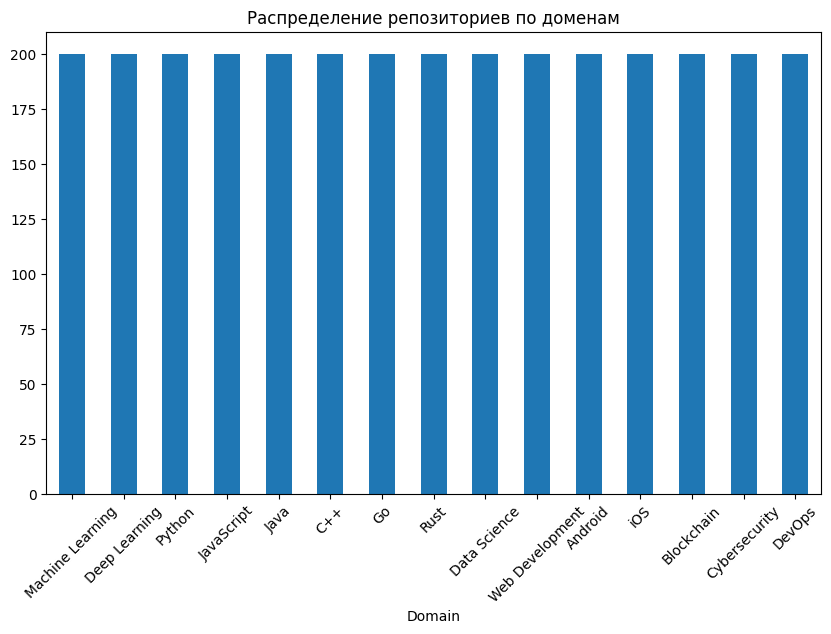

Классы после кодирования: ['Android' 'Blockchain' 'C++' 'Cybersecurity' 'Data Science'
 'Deep Learning' 'DevOps' 'Go' 'Java' 'JavaScript' 'Machine Learning'
 'Python' 'Rust' 'Web Development' 'iOS']


In [2]:
# Общая информация о типах данных и пропусках
df.info()

# Проверим баланс классов в колонке Domain
plt.figure(figsize=(10, 6))
df['Domain'].value_counts().plot(kind='bar')
plt.title('Распределение репозиториев по доменам')
plt.xticks(rotation=45)
plt.show()

# Для KNN нам нужны числовые признаки. Выберем основные показатели активности.
# Также удалим строки, если в них есть критические пропуски.
features = ['Stars Count', 'Forks Count', 'Watchers Count', 'Open Issues Count', 'Size (KB)']
target = 'Domain'

# Очистим данные от строк, где нет целевой переменной (если такие есть)
df = df.dropna(subset=[target] + features)

X = df[features]
y = df[target]

# Т.к. целевая переменная текстовая, переведем её в числа
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Классы после кодирования:", le.classes_)

In [3]:
# Разбиваем на обучающую и тестовую выборки (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Базовый KNN с параметрами по умолчанию (n=5)
knn_simple = KNeighborsClassifier(n_neighbors=5)
knn_simple.fit(X_train, y_train)

simple_score = knn_simple.score(X_test, y_test)
print(f"Точность (accuracy) без масштабирования: {simple_score:.4f}")

Точность (accuracy) без масштабирования: 0.1767


In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Обучим ту же модель на отмасштабированных данных
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)

scaled_score = knn_scaled.score(X_test_scaled, y_test)
print(f"Точность (accuracy) после масштабирования: {scaled_score:.4f}")

Точность (accuracy) после масштабирования: 0.2633


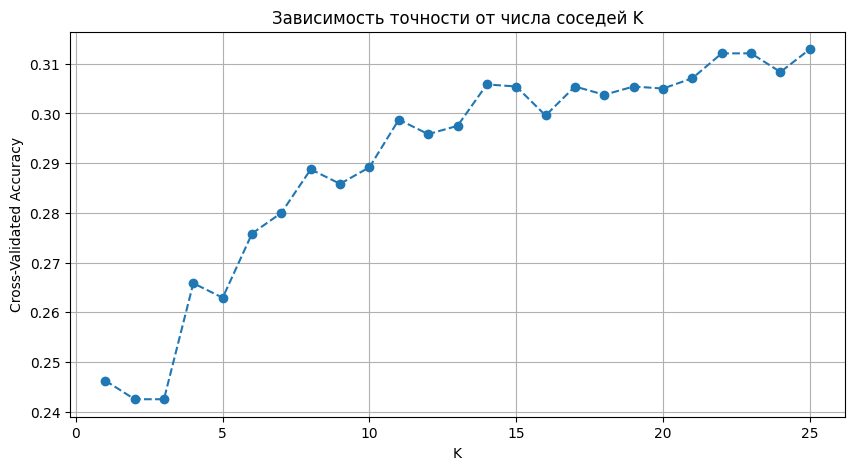

Лучшее значение K на кросс-валидации: 25


In [5]:
k_values = range(1, 26)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    # Используем кросс-валидацию для более надежной оценки
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    accuracies.append(scores.mean())

plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracies, marker='o', linestyle='--')
plt.title('Зависимость точности от числа соседей K')
plt.xlabel('K')
plt.ylabel('Cross-Validated Accuracy')
plt.grid()
plt.show()

best_k = k_values[np.argmax(accuracies)]
print(f"Лучшее значение K на кросс-валидации: {best_k}")

In [6]:
param_grid = {
    'n_neighbors': [3, 5, 7, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_scaled, y_train)

print("Лучшие параметры:", grid.best_params_)
print(f"Лучшая точность на CV: {grid.best_score_:.4f}")

# Оценка итоговой модели на тестовых данных
final_model = grid.best_estimator_
y_pred = final_model.predict(X_test_scaled)

print("\nИтоговый отчет по метрикам:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Лучшие параметры: {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'uniform'}
Лучшая точность на CV: 0.3096

Итоговый отчет по метрикам:
                  precision    recall  f1-score   support

         Android       0.07      0.05      0.06        39
      Blockchain       0.59      0.44      0.50        39
             C++       0.17      0.24      0.20        37
   Cybersecurity       0.52      0.64      0.57        39
    Data Science       0.43      0.38      0.41        42
   Deep Learning       0.07      0.07      0.07        41
          DevOps       0.45      0.26      0.33        35
              Go       0.35      0.39      0.37        46
            Java       0.19      0.26      0.22        39
      JavaScript       0.11      0.11      0.11        37
Machine Learning       0.22      0.12      0.16        49
          Python       0.39      0.69      0.50        51
            Rust       0.30      0.32      0.31        34
 Web Development       1.00      0.53      0.